<p style="padding:8px;background-color:Orange;color:White;font-family:newtimeroman;font-weight: bold;text-align:center;font-size:28px;"> 👤 CUSTOMER CHURN ↓ PREDICTION 📈</p>


<center> <img src="https://i.ibb.co/5cq4fQz/CHURN-IMAGESS.jpg" > </center>

# Import Libraries

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import*  
import joblib


# Import Data

In [2]:
data = pd.read_excel(r"D:\Projects DA\Customer_Churn\vw_ChurnData.xlsx")

In [3]:
data.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,221958-KAR,Female,33,Yes,Delhi,3,10,Deal 2,Yes,No,...,Bank Withdrawal,50.904325,509.043247,0.00,0,98.43,607.473247,Stayed,Others,Others
1,231932-RAJ,Female,53,No,Punjab,0,46,Deal 4,Yes,No,...,Mailed Check,67.358596,3098.495418,0.00,0,395.85,3494.345418,Stayed,Others,Others
2,210268-TAM,Female,54,Yes,West Bengal,5,50,Deal 5,Yes,Yes,...,Bank Withdrawal,51.935517,2596.775841,0.00,0,410.52,3007.295841,Stayed,Others,Others
3,621430-RAJ,Female,42,Yes,Delhi,3,39,Deal 3,Yes,No,...,Bank Withdrawal,54.462510,2124.037906,38.07,0,392.76,2478.727906,Stayed,Others,Others
4,275203-RAJ,Female,36,Yes,Delhi,14,43,Deal 4,Yes,No,...,Bank Withdrawal,53.740063,2310.822704,0.00,0,356.09,2666.912704,Stayed,Others,Others


# Interpreting the Dataset

**In this Telecom Company Dataset, we have:**

● **Churn Information**
- 'Customer_Status' (Target Variable)
- 'Churn_Category', 'Churn_Reason' (Post-churn insights)

● **Services Provided**
- 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Internet_Type',
  'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
  'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
  'Streaming_Music', 'Unlimited_Data'

● **Billing & Financial Features**
- 'Monthly_Charge', 'Total_Charges', 'Total_Refunds',
  'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges',
  'Total_Revenue'

● **Account & Contract Information**
- 'Contract', 'Paperless_Billing', 'Payment_Method'

● **Customer Behavior**
- 'Tenure_in_Months', 'Number_of_Referrals', 'Value_Deal'

● **Demographics**
- 'Gender', 'Age', 'Married', 'State'

In [4]:
data['Customer_Status'].unique()

array(['Stayed', 'Churned'], dtype=object)

In [5]:
data['Customer_Status'].value_counts()

Customer_Status
Stayed     71835
Churned    17225
Name: count, dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89060 entries, 0 to 89059
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  89060 non-null  object 
 1   Gender                       89060 non-null  object 
 2   Age                          89060 non-null  int64  
 3   Married                      89060 non-null  object 
 4   State                        89060 non-null  object 
 5   Number_of_Referrals          89060 non-null  int64  
 6   Tenure_in_Months             89060 non-null  int64  
 7   Value_Deal                   74235 non-null  object 
 8   Phone_Service                89060 non-null  object 
 9   Multiple_Lines               89060 non-null  object 
 10  Internet_Service             89060 non-null  object 
 11  Internet_Type                89060 non-null  object 
 12  Online_Security              89060 non-null  object 
 13  Online_Backup   

# Exploratory Data Analysis (EDA) 

In [7]:
#Drop columns that won't used for prediction
data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'],axis=1)

In [8]:
data.head(2)

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,...,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status
0,Female,33,Yes,Delhi,3,10,Deal 2,Yes,No,Yes,...,Two Year,No,Bank Withdrawal,50.904325,509.043247,0.0,0,98.43,607.473247,Stayed
1,Female,53,No,Punjab,0,46,Deal 4,Yes,No,Yes,...,Month-to-Month,No,Mailed Check,67.358596,3098.495418,0.0,0,395.85,3494.345418,Stayed


In [9]:
data.isnull().sum()

Gender                             0
Age                                0
Married                            0
State                              0
Number_of_Referrals                0
Tenure_in_Months                   0
Value_Deal                     14825
Phone_Service                      0
Multiple_Lines                     0
Internet_Service                   0
Internet_Type                      0
Online_Security                    0
Online_Backup                      0
Device_Protection_Plan             0
Premium_Support                    0
Streaming_TV                       0
Streaming_Movies                   0
Streaming_Music                    0
Unlimited_Data                     0
Contract                           0
Paperless_Billing                  0
Payment_Method                     0
Monthly_Charge                     0
Total_Charges                      0
Total_Refunds                      0
Total_Extra_Data_Charges           0
Total_Long_Distance_Charges        0
T

In [10]:
data.shape

(89060, 29)

In [11]:
data["Value_Deal"].unique()

array(['Deal 2', 'Deal 4', 'Deal 5', 'Deal 3', nan, 'Deal 1'],
      dtype=object)

In [ ]:
# Fillna with mode values
data["Value_Deal"] = data["Value_Deal"].fillna(data["Value_Deal"].mode()[0])

In [13]:
data.columns

Index(['Gender', 'Age', 'Married', 'State', 'Number_of_Referrals',
       'Tenure_in_Months', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
       'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
       'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV',
       'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data', 'Contract',
       'Paperless_Billing', 'Payment_Method', 'Monthly_Charge',
       'Total_Charges', 'Total_Refunds', 'Total_Extra_Data_Charges',
       'Total_Long_Distance_Charges', 'Total_Revenue', 'Customer_Status'],
      dtype='object')

In [14]:
data.isnull().sum()

Gender                         0
Age                            0
Married                        0
State                          0
Number_of_Referrals            0
Tenure_in_Months               0
Value_Deal                     0
Phone_Service                  0
Multiple_Lines                 0
Internet_Service               0
Internet_Type                  0
Online_Security                0
Online_Backup                  0
Device_Protection_Plan         0
Premium_Support                0
Streaming_TV                   0
Streaming_Movies               0
Streaming_Music                0
Unlimited_Data                 0
Contract                       0
Paperless_Billing              0
Payment_Method                 0
Monthly_Charge                 0
Total_Charges                  0
Total_Refunds                  0
Total_Extra_Data_Charges       0
Total_Long_Distance_Charges    0
Total_Revenue                  0
Customer_Status                0
dtype: int64

In [15]:
data.duplicated().sum()

np.int64(0)

In [16]:
data.columns

Index(['Gender', 'Age', 'Married', 'State', 'Number_of_Referrals',
       'Tenure_in_Months', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
       'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
       'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV',
       'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data', 'Contract',
       'Paperless_Billing', 'Payment_Method', 'Monthly_Charge',
       'Total_Charges', 'Total_Refunds', 'Total_Extra_Data_Charges',
       'Total_Long_Distance_Charges', 'Total_Revenue', 'Customer_Status'],
      dtype='object')

In [17]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

num_cols

['Age',
 'Number_of_Referrals',
 'Tenure_in_Months',
 'Monthly_Charge',
 'Total_Charges',
 'Total_Refunds',
 'Total_Extra_Data_Charges',
 'Total_Long_Distance_Charges',
 'Total_Revenue']

In [18]:
#Finding any absurd values in Numeric Columns
data[num_cols].describe()

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
count,89060.000000,89060.000000,89060.000000,89060.000000,89060.000000,89060.000000,89060.000000,89060.000000,89060.000000
mean,50.966416,6.999360,38.518190,61.485176,2241.146114,2.546852,3.865259,250.235209,2488.834471
std,19.333343,4.328535,19.536269,25.118840,1442.503347,8.845263,9.823344,144.277353,1450.025433
min,18.000000,0.000000,1.000000,20.000000,20.000000,0.000000,0.000000,0.010000,5.944825
25%,34.000000,3.000000,24.000000,42.518556,1155.000444,0.000000,0.000000,125.677500,1398.305000
50%,51.000000,7.000000,39.000000,60.919667,1993.334655,0.000000,0.000000,250.205000,2246.559752
75%,68.000000,11.000000,53.000000,79.417392,3090.412921,0.000000,0.000000,375.112500,3344.935101
max,84.000000,14.000000,72.000000,120.000000,8640.000000,50.000000,50.000000,500.000000,9107.550000


In [19]:
#Analysing object data tyeps
data.describe(include = 'O')

,Gender,Married,State,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Customer_Status
count,89060,89060,89060,89060,89060,89060,89060,89060,89060,89060,89060,89060,89060,89060,89060,89060,89060,89060,89060,89060
unique,2,2,10,5,2,2,2,3,2,2,2,2,2,2,2,2,3,2,3,2
top,Female,Yes,Delhi,Deal 5,Yes,No,Yes,DSL,No,Yes,No,No,No,Yes,Yes,Yes,Month-to-Month,No,Bank Withdrawal,Stayed
freq,53545,44679,26181,29783,80135,44563,71094,59881,44530,44559,44835,44654,44622,44639,44617,44554,31987,44790,74207,71835


In [20]:
##To see whole columns
pd.set_option('display.max_columns', None)
data

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status
0,Female,33,Yes,Delhi,3,10,Deal 2,Yes,No,Yes,DSL,No,No,No,Yes,No,No,No,Yes,Two Year,No,Bank Withdrawal,50.904325,509.043247,0.00,0,98.43,607.473247,Stayed
1,Female,53,No,Punjab,0,46,Deal 4,Yes,No,Yes,DSL,Yes,Yes,No,No,Yes,Yes,No,Yes,Month-to-Month,No,Mailed Check,67.358596,3098.495418,0.00,0,395.85,3494.345418,Stayed
2,Female,54,Yes,West Bengal,5,50,Deal 5,Yes,Yes,Yes,DSL,No,No,Yes,Yes,No,Yes,Yes,Yes,Two Year,No,Bank Withdrawal,51.935517,2596.775841,0.00,0,410.52,3007.295841,Stayed
3,Female,42,Yes,Delhi,3,39,Deal 3,Yes,No,Yes,DSL,No,Yes,No,No,No,No,Yes,No,One Year,Yes,Bank Withdrawal,54.462510,2124.037906,38.07,0,392.76,2478.727906,Stayed
4,Female,36,Yes,Delhi,14,43,Deal 4,Yes,No,Yes,DSL,Yes,Yes,Yes,No,No,No,Yes,No,One Year,No,Bank Withdrawal,53.740063,2310.822704,0.00,0,356.09,2666.912704,Stayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89055,Male,23,No,Kerala,4,46,Deal 5,Yes,Yes,Yes,DSL,Yes,Yes,No,Yes,No,Yes,No,Yes,Month-to-Month,No,Bank Withdrawal,20.000000,920.000000,0.00,0,468.53,1388.530000,Stayed
89056,Female,29,Yes,Rajasthan,9,72,Deal 5,Yes,No,No,Cable,No,Yes,No,No,No,Yes,Yes,No,One Year,Yes,Bank Withdrawal,75.411134,5429.601677,9.18,0,482.43,5902.851677,Stayed
89057,Male,33,No,Tamil Nadu,5,29,Deal 3,Yes,Yes,Yes,Fiber Optic,Yes,No,Yes,No,Yes,No,Yes,No,Two Year,No,Bank Withdrawal,66.936916,1941.170553,0.00,0,387.43,2328.600553,Stayed
89058,Male,80,Yes,West Bengal,5,61,Deal 3,Yes,Yes,No,DSL,No,No,Yes,No,No,No,Yes,No,Two Year,Yes,Bank Withdrawal,42.057849,2565.528765,0.00,0,140.59,2706.118765,Stayed


In [ ]:
#List of object columns for LabelEncoding
encode_columns = ['Gender',
 'Married',
 'State',
 'Value_Deal',
 'Phone_Service',
 'Multiple_Lines',
 'Internet_Service',
 'Internet_Type',
 'Online_Security',
 'Online_Backup',
 'Device_Protection_Plan',
 'Premium_Support',
 'Streaming_TV',
 'Streaming_Movies',
 'Streaming_Music',
 'Unlimited_Data',
 'Contract',
 'Paperless_Billing',
 'Payment_Method']

In [22]:
#Encode Categorical columns except target Column.
label_encoders = {}
for column in encode_columns:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

In [23]:
#Manually encode the target variable 'Customer_Status'
data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned':1})

In [24]:
#Split data into features and target
X = data.drop('Customer_Status',axis=1)
y = data['Customer_Status']

In [25]:
#Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [26]:
y.shape

(89060,)

In [27]:
#Train Random Forest Model
#Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

#Train the model
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
#Evaluate Model
#Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[13686   666]
 [  866  2594]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     14352
           1       0.80      0.75      0.77      3460

    accuracy                           0.91     17812
   macro avg       0.87      0.85      0.86     17812
weighted avg       0.91      0.91      0.91     17812



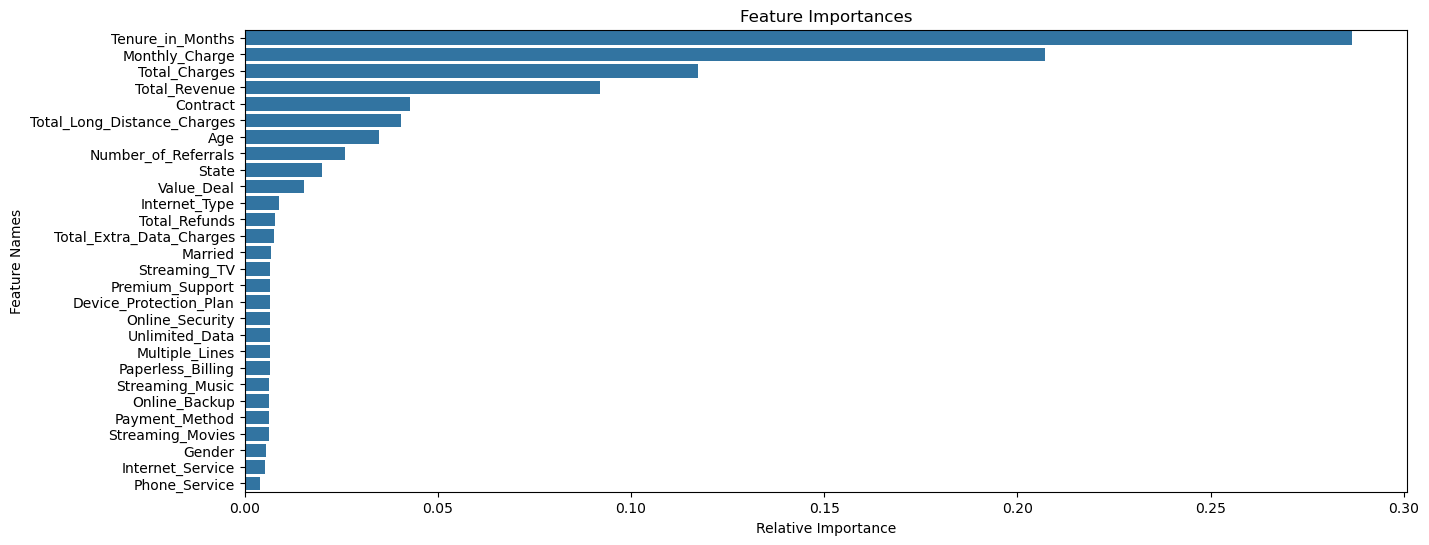

In [29]:
#Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances) [::-1]

#Plot the feature importances
plt.figure(figsize=(15,6))
sns.barplot(x=importances[indices],y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()

# Import the data for Churn_Prediction

In [31]:

new_data=pd.read_excel(r"D:\Projects DA\Customer_Churn\vw_JoinData.xlsx")
new_data.head()

In [39]:
new_data['Customer_Status'].unique()

array(['Joined'], dtype=object)

In [ ]:
new_data['Customer_Status'].unique()

In [35]:
new_data.isnull().sum()

Customer_ID                       0
Gender                            0
Age                               0
Married                           0
State                             0
Number_of_Referrals               0
Tenure_in_Months                  0
Value_Deal                     1619
Phone_Service                     0
Multiple_Lines                    0
Internet_Service                  0
Internet_Type                     0
Online_Security                   0
Online_Backup                     0
Device_Protection_Plan            0
Premium_Support                   0
Streaming_TV                      0
Streaming_Movies                  0
Streaming_Music                   0
Unlimited_Data                    0
Contract                          0
Paperless_Billing                 0
Payment_Method                    0
Monthly_Charge                    0
Total_Charges                     0
Total_Refunds                     0
Total_Extra_Data_Charges          0
Total_Long_Distance_Charges 

In [43]:
# Fillna with mean values
new_data["Value_Deal"] = new_data["Value_Deal"].fillna(new_data["Value_Deal"].mode()[0])

In [44]:
new_data["Value_Deal"].isnull().sum()

np.int64(0)

In [46]:
# Retain the original DataFrame to preserve unencoded columns
original_data = new_data.copy()


In [47]:
# Retain the Customer_ID column
customer_ids = new_data['Customer_ID']

In [48]:
# Drop columns that won't be used for prediction in the encoded DataFrame
new_data = new_data.drop(
    ['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'],
    axis=1
)

In [49]:
# Encode categorical variables using the saved Label Encoders
for column in new_data.select_dtypes(include=['object']).columns:
    new_data[column] = label_encoders[column].transform(new_data[column])

In [51]:
# Make predictions
new_predictions = rf_model.predict(new_data)

# Add predictions to the original DataFrame
original_data['Customer_Status_Predicted'] = new_predictions

# Filter the DataFrame to include only records predicted as "Churned"
original_data = original_data[
    original_data['Customer_Status_Predicted'] == 1
]

In [52]:
# Save the results
original_data.to_csv("D:\Projects DA\Customer_Churn\Predicted_Churn.csv",
    index=False)